In [1]:
# Step 1: Import the libraries we need
# Why this step comes first:
# Before we build any neural network, we must import the tools.
# These libraries help us load data, scale features, build the model, and measure results.

import pandas as pd
import numpy as np

from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping

In [3]:
new_feature_data =  pd.read_csv("new_feautre_data.csv",index_col= "Date" ,parse_dates = ["Date"])

In [5]:
new_feature_data

,AXISBANK.NS,BAJFINANCE.NS,BHARTIARTL.NS,HCLTECH.NS,HDFCBANK.NS,HINDUNILVR.NS,ICICIBANK.NS,INFY.NS,ITC.NS,KOTAKBANK.NS,...,INFY.NS_Lag_200_ema,ITC.NS_Lag_200_ema,KOTAKBANK.NS_Lag_200_ema,LT.NS_Lag_200_ema,M&M.NS_Lag_200_ema,RELIANCE.NS_Lag_200_ema,SBIN.NS_Lag_200_ema,TCS.NS_Lag_200_ema,^NSEI_Lag_200_ema,Target
Date,,,,,,,,,,,,,,,,,,,,,
2010-10-21,0.034513,0.007545,0.048160,-0.005884,0.012573,0.043518,0.013996,0.018577,0.037101,0.002787,...,0.000947,0.001594,0.002140,0.001406,0.001648,0.000228,0.002308,0.001885,0.001086,0
2010-10-22,-0.028484,0.001683,-0.010887,-0.010144,-0.016391,-0.017114,0.001990,0.006143,-0.018232,-0.017144,...,0.001150,0.002002,0.002148,0.001606,0.001852,0.000572,0.002650,0.002134,0.001301,1
2010-10-25,0.000376,0.023401,0.011183,0.018303,-0.009479,0.016625,0.009015,-0.011198,-0.012047,0.015254,...,0.001207,0.001770,0.001926,0.001453,0.001649,0.000567,0.002659,0.002721,0.001219,0
2010-10-26,-0.003454,-0.009205,-0.025226,-0.003539,-0.001433,-0.026633,-0.009634,-0.001757,0.015254,-0.020018,...,0.001065,0.001612,0.002079,0.001523,0.001842,0.000651,0.002746,0.002981,0.001280,0
2010-10-27,-0.008567,-0.008455,-0.021054,-0.013685,-0.020678,-0.017759,-0.021807,-0.011228,-0.022969,-0.024688,...,0.001033,0.001768,0.001826,0.001539,0.001857,0.000732,0.002507,0.002900,0.001221,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-23,0.006788,0.002690,0.005561,-0.004378,0.016515,0.002140,0.006499,0.001118,0.020450,0.001032,...,0.001085,0.000026,-0.000210,0.000310,0.001238,-0.001299,0.000348,0.000218,-0.000011,0
2024-12-24,-0.000232,-0.008556,-0.001892,-0.003184,-0.001611,-0.001433,0.000347,-0.007957,0.008817,0.002118,...,0.001085,0.000229,-0.000197,0.000336,0.001236,-0.001147,0.000456,0.000187,0.000059,1
2024-12-26,-0.002041,0.001108,0.009801,0.002001,-0.004096,-0.001200,0.000077,-0.000865,-0.003140,0.002142,...,0.000995,0.000314,-0.000174,0.000331,0.001289,-0.001132,0.000341,0.000236,0.000048,1


In [7]:
X = new_feature_data.drop(columns= ["Target"])
Y = new_feature_data["Target"]

In [9]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.2, shuffle=False
)

In [11]:

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [19]:
# testing target balance 

print("\nTrain target balance:")
print(y_train.value_counts(normalize=True).round(4))

print("\nValidation target balance:")
print(y_test.value_counts(normalize=True).round(4))




Train target balance:
1    0.5291
0    0.4709
Name: Target, dtype: float64

Validation target balance:
1    0.5474
0    0.4526
Name: Target, dtype: float64


In [21]:
model = keras.Sequential([
    layers.Input(shape=(X_train_scaled.shape[1],)),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.2),
    layers.Dense(32, activation="relu"),
    layers.Dropout(0.2),
    layers.Dense(1, activation="sigmoid")
])

# Compile the model
# binary_crossentropy is used for 0/1 classification
# adam is a common optimizer that works well for beginners
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# Show model summary
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 64)                10240     
                                                                 
 dropout (Dropout)           (None, 64)                0         
                                                                 
 dense_1 (Dense)             (None, 32)                2080      
                                                                 
 dropout_1 (Dropout)         (None, 32)                0         
                                                                 
 dense_2 (Dense)             (None, 1)                 33        
                                                                 
Total params: 12,353
Trainable params: 12,353
Non-trainable params: 0
_________________________________________________________________


In [28]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=100,
    callbacks=[early_stop]
)

Epoch 1/100
87/87 [==============================] - 4s 15ms/step - loss: 0.6927 - accuracy: 0.5230 - val_loss: 0.6904 - val_accuracy: 0.5474
Epoch 2/100
87/87 [==============================] - 0s 5ms/step - loss: 0.6911 - accuracy: 0.5280 - val_loss: 0.6888 - val_accuracy: 0.5474
Epoch 3/100
87/87 [==============================] - 0s 5ms/step - loss: 0.6896 - accuracy: 0.5252 - val_loss: 0.6894 - val_accuracy: 0.5489
Epoch 4/100
87/87 [==============================] - 0s 6ms/step - loss: 0.6883 - accuracy: 0.5377 - val_loss: 0.6899 - val_accuracy: 0.5546
Epoch 5/100
87/87 [==============================] - 1s 6ms/step - loss: 0.6864 - accuracy: 0.5413 - val_loss: 0.6916 - val_accuracy: 0.5172
Epoch 6/100
87/87 [==============================] - 1s 6ms/step - loss: 0.6839 - accuracy: 0.5543 - val_loss: 0.6900 - val_accuracy: 0.5474
Epoch 7/100
87/87 [==============================] - 1s 8ms/step - loss: 0.6824 - accuracy: 0.5543 - val_loss: 0.6908 - val_accuracy: 0.5532
Epoch 8/100


In [30]:
test_prob = model.predict(X_test_scaled)

# Convert probabilities to class labels using 0.5 threshold
test_pred = (test_prob >= 0.5).astype(int).ravel()

print("Test Accuracy:", round(accuracy_score(y_test, test_pred), 4))
print("Test Precision:", round(precision_score(y_test, test_pred, zero_division=0), 4))
print("Test Recall:", round(recall_score(y_test, test_pred, zero_division=0), 4))
print("Test F1:", round(f1_score(y_test, test_pred, zero_division=0), 4))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, test_pred))

print("\nClassification Report:")
print(classification_report(y_test, test_pred))

22/22 [==============================] - 1s 3ms/step
Test Accuracy: 0.4971
Test Precision: 0.5403
Test Recall: 0.5459
Test F1: 0.5431

Confusion Matrix:
[[138 177]
 [173 208]]

Classification Report:
              precision    recall  f1-score   support

           0       0.44      0.44      0.44       315
           1       0.54      0.55      0.54       381

    accuracy                           0.50       696
   macro avg       0.49      0.49      0.49       696
weighted avg       0.50      0.50      0.50       696



In [34]:
all_data  = pd.read_csv("new_nifty_top15_prices_2010_2024.csv",index_col= "Date" ,parse_dates = ["Date"]).dropna()

In [38]:
all_data_return = all_data.pct_change()

In [42]:
# Get HDFC actual log returns on the test period
test_actual_returns = all_data_return.loc[X_test.index, '^NSEI']

# Strategy: Buy (hold) when model predicts UP (1), stay out when DOWN (0)
strategy_returns = test_actual_returns * test_pred

# Buy-and-hold: just hold HDFC entire test period
buyhold_returns = test_actual_returns

# Cumulative returns
cum_strategy = (1 + strategy_returns).cumprod()
cum_buyhold  = (1 + buyhold_returns).cumprod()

print("=" * 50)
print("BACKTESTING RESULTS")
print("=" * 50)
print(f"Strategy Final Return  : {(cum_strategy.iloc[-1]-1)*100:.2f}%")
print(f"Buy & Hold Return      : {(cum_buyhold.iloc[-1]-1)*100:.2f}%")
print(f"Strategy Outperforms   : {cum_strategy.iloc[-1] > cum_buyhold.iloc[-1]}")

BACKTESTING RESULTS
Strategy Final Return  : 100.84%
Buy & Hold Return      : 43.32%
Strategy Outperforms   : True


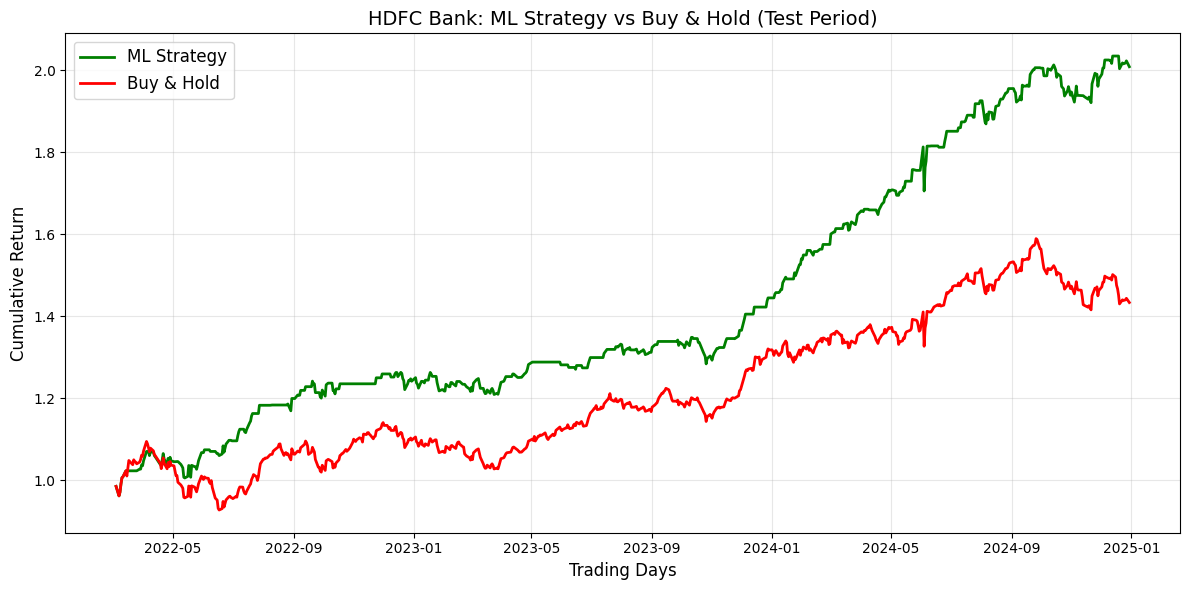

In [44]:
import matplotlib.pyplot as plt

# Plot cumulative returns
plt.figure(figsize=(12, 6))
plt.plot(cum_strategy, label='ML Strategy', color='green', linewidth=2)
plt.plot(cum_buyhold, label='Buy & Hold', color='red', linewidth=2)
plt.title('HDFC Bank: ML Strategy vs Buy & Hold (Test Period)', fontsize=14)
plt.xlabel('Trading Days', fontsize=12)
plt.ylabel('Cumulative Return', fontsize=12)
plt.legend(fontsize=12)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()